In [1]:
!pip install langchain_google_genai langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.15
    Uninstalling google-ai-generativelanguage-0.6.15:
      Successfully uninstalled google-ai-generativelanguage-0.6.15
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [4]:
import os
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")
langsmith_api_key = os.getenv("LANGSMITH_API_KEY")

In [5]:
import getpass


#Langchain mensajes
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Langchain embedding model (Google)
from langchain_google_genai import GoogleGenerativeAIEmbeddings

#Langchain document loaders
from langchain_core.documents.base import Document
from langchain_community.document_loaders import WebBaseLoader

#Langchain text splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

#Vector store (Chroma)
from langchain_core.vectorstores import InMemoryVectorStore

#Herramientas
from langchain_core.tools import tool
from langchain_core.runnables.base import RunnableBinding
from langchain_classic.tools.retriever import create_retriever_tool

#Message state
from langgraph.graph.message import MessagesState
from typing import TypedDict

#Workflow
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Memoria
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.memory import InMemorySaver

from IPython.display import Image, display

#### LangSmith API keys

In [6]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "LangSmith_Fundamentos"

In [ ]:
# Ingresa el API key - Gemini
# os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


In [ ]:
# Ingresa el API key - LangSmith
# os.environ["LANGSMITH_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


In [7]:
#Inicializamos nuestro modelo chat
llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

#### **Aplicación 01:** ChatBot

In [8]:
# System message
mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '¿Cuál es la capital de Alemania?'

# Dentro de la lista se pueden especificar múltiples tipos de mensaje
prompt: list[SystemMessage, HumanMessage] = [SystemMessage(mensaje_sistema), HumanMessage(mensaje_humano)]

response: AIMessage = llm.invoke(prompt)

# Notar que la respuesta del modelo ahora es más detallada. La instrucción en el SystemMessage tuvo un efecto significativo en la salida del modelo.
print(f'{response.content}')

La capital de Alemania es **Berlín**.

Berlín tiene una rica y compleja historia, habiendo sido la capital del Reino de Prusia, el Imperio Alemán, la República de Weimar y la Alemania nazi. Tras la Segunda Guerra Mundial, la ciudad fue dividida en Berlín Oriental (capital de la República Democrática Alemana) y Berlín Occidental (parte de la República Federal de Alemania), convirtiéndose en un símbolo de la Guerra Fría y la división ideológica, marcada por el Muro de Berlín. Tras la reunificación alemana en 1990, Berlín recuperó su estatus como capital de toda Alemania.


#### **Aplicación 02:** RAG

In [9]:
#El módulo GoogleGenerativeAIEmbeddings nos permite acceder al modelo de gemini
embedding_model: GoogleGenerativeAIEmbeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [10]:
#WebBaseLoader carga información de la web y transforma el código html en documentos - requiere la dirección de la página web
loader: WebBaseLoader = WebBaseLoader("https://www.ibm.com/es-es/think/topics/large-language-models")

#Luego de instanciar la clase, se pueden cargar los documentos con el método load
documento_web: list = loader.load()

In [11]:
# Este loader trata de separa el texto primero en párrafos, luego en oraciones y por último en palabras
splitter_documento:RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    length_function=len
)

#Con el método split_documentos se dividen los documentos
textos_split_recursive: list[Document] = splitter_documento.split_documents(documento_web)

In [12]:
#Utilizamos un vector store en memoria
vectorstore = InMemoryVectorStore.from_documents(
    documents=textos_split_recursive, embedding=embedding_model
)
retriever = vectorstore.as_retriever()

In [13]:
#Esta herramienta nos permite usar nuestro retriever como una herramienta
@tool
def retriever_tool(query: str):
    """Recupera documentos relevantes acerca de modelos LLM"""
    return retriever.invoke(query)

In [14]:
#Anexamos las herramientas al modelo
tools: list = [retriever_tool]
modelo: RunnableBinding = llm.bind_tools( tools )

In [15]:
#Definición del estado del grafo
class Estado(MessagesState):
    ...

In [16]:
mensaje_sistema: SystemMessage = SystemMessage(
    'Eres un asistente experto en Modelos de Lenguaje Grandes (LLMs).'
    'Tu objetivo es responder preguntas, explicar conceptos complejos y ayudar al usuario a entender el funcionamiento, la arquitectura y las aplicaciones de los LLMs.'
    'Consulta los documentos retornados por la la herramienta retriever_tool para generar una mejor respuesta.'
    'Proporciona respuestas claras, precisas y bien estructuradas.')

def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage = mensaje_sistema
  response: AIMessage = modelo.invoke([prompt] + state["messages"])
  return {"messages": [response]}

In [17]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tool_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

workflow.add_edge("tools", "Asistente")

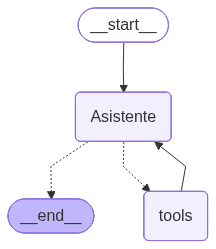

In [18]:
#Inicializamos la memoria
memory: InMemorySaver = MemorySaver()
workflow_compilado_memoria: CompiledStateGraph = workflow.compile(checkpointer=memory)

display(Image(workflow_compilado_memoria.get_graph().draw_mermaid_png()))

In [19]:
#Inicializamos la configuración, se debe especificar el hilo de la conversación
config: dict = {"configurable": {"thread_id": "1"}}

messages: list[HumanMessage] = [HumanMessage(content="¿Cuáles son los casos de uso de los LLMs?")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado_memoria.invoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

¿Cuáles son los casos de uso de los LLMs?
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (8faff348-cfac-4019-a72b-50546b02b7fb)
 Call ID: 8faff348-cfac-4019-a72b-50546b02b7fb
  Args:
    query: casos de uso de LLMs
================================= Tool Message =================================
Name: retriever_tool

[Document(id='d950844b-2695-495e-8e21-1e5a572a1fa7', metadata={'source': 'https://www.ibm.com/es-es/think/topics/large-language-models', 'title': '¿Qué son los grandes modelos de lenguaje (LLM)? | IBM ', 'description': 'Los grandes modelos de lenguaje son sistemas de IA capaces de comprender y generar lenguaje humano mediante el procesamiento de grandes cantidades de datos de texto.\n\n\n\n', 'language': 'es-es'}, page_content='Casos de uso de modelos de lenguaje de gran tamaño\xa0\n    \n\n\nLos LLM están redefiniendo los procesos